# ---------- ASSIGNMENT 5 (AI) - GENERATIVE ADVERSARIAL NETWORKS ------------

Question: Generating Fashion Products with GAN

Dataset Problem: Use the Fashion MNIST dataset to train a GAN for generating new fashion product images.

The Fashion-MNIST dataset is proposed as a more challenging replacement dataset for the MNIST dataset. It is a dataset comprised of 60,000 small square 28 Å~ 28-pixel grayscale images of items of 10 types of clothing, such as shoes, t-shirts, dresses, and more. The mapping of all 0-9 integers to class labels are listed below.

0: T-shirt/top

1: Trouser

2: Pullover

3: Dress

4: Coat

5: Sandal

6: Shirt

7: Sneaker

8: Bag

9: Ankle boot

Download data from: https://github.com/zalandoresearch/fashion-mnist

In [2]:
# Import Libraries

!pip install torch torchvision
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
# Load Fashion-MNIST dataset

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.66MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.02MB/s]


In [4]:
# Define Generator

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [5]:
# Define Discriminator

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [6]:
# Initialize Model and Optimizers

G = Generator()
D = Discriminator()

criterion = nn.BCELoss()
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002)
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002)

In [7]:
# Training Loop

epochs = 50

for epoch in range(epochs):
    for real_images, _ in loader:
        batch_size = real_images.size(0)
        real_images = real_images.view(batch_size, -1)

        # Labels
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # Train Discriminator
        noise = torch.randn(batch_size, 100)
        fake_images = G(noise)

        d_loss_real = criterion(D(real_images), real_labels)
        d_loss_fake = criterion(D(fake_images.detach()), fake_labels)
        d_loss = d_loss_real + d_loss_fake

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        g_loss = criterion(D(fake_images), real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch [1/50] | D Loss: 0.0739 | G Loss: 3.6471
Epoch [2/50] | D Loss: 0.0781 | G Loss: 5.6932
Epoch [3/50] | D Loss: 0.1089 | G Loss: 2.9915
Epoch [4/50] | D Loss: 0.1794 | G Loss: 3.7540
Epoch [5/50] | D Loss: 0.3004 | G Loss: 3.6844
Epoch [6/50] | D Loss: 0.2299 | G Loss: 4.5870
Epoch [7/50] | D Loss: 0.3365 | G Loss: 4.0750
Epoch [8/50] | D Loss: 0.2125 | G Loss: 2.7782
Epoch [9/50] | D Loss: 0.1782 | G Loss: 5.0100
Epoch [10/50] | D Loss: 0.3049 | G Loss: 3.3431
Epoch [11/50] | D Loss: 0.3456 | G Loss: 3.4193
Epoch [12/50] | D Loss: 0.2241 | G Loss: 4.1818
Epoch [13/50] | D Loss: 0.6435 | G Loss: 2.5883
Epoch [14/50] | D Loss: 0.4181 | G Loss: 2.2452
Epoch [15/50] | D Loss: 0.3674 | G Loss: 3.2769
Epoch [16/50] | D Loss: 0.6462 | G Loss: 3.1815
Epoch [17/50] | D Loss: 0.5934 | G Loss: 2.9207
Epoch [18/50] | D Loss: 0.5423 | G Loss: 3.3917
Epoch [19/50] | D Loss: 0.7706 | G Loss: 2.4292
Epoch [20/50] | D Loss: 0.2695 | G Loss: 3.3302
Epoch [21/50] | D Loss: 0.6708 | G Loss: 3.1370
E

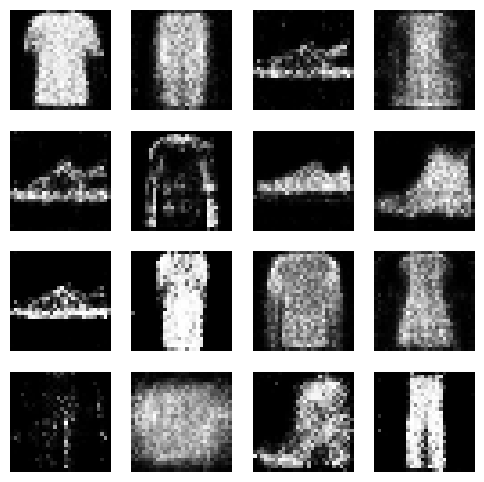

In [8]:
# Generate new Fashion Images

noise = torch.randn(16, 100)
generated_images = G(noise).view(-1, 28, 28)

plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(generated_images[i].detach(), cmap='gray')
    plt.axis('off')
plt.show()

### **Advantages of GAN for Fashion-MNIST:**

* Generates new product designs

* Data augmentation for fashion models

* Useful for design inspiration

* Unsupervised learning

### **Conclusion:**

Using GANs on Fashion-MNIST, we successfully learned the underlying fashion distribution and generated realistic clothing images. This approach can be extended to:

* Conditional GANs (class-specific clothes)

* High-resolution fashion datasets

* Virtual try-on systems